<h4> Zadanie1: Analizujemy dane Amazon Fine Foods review. Celem zadania jest budowa klasyfikatora w oparciu o sieci neuronowe, na podstawie reprezentacji BoW, SoW lub TF-IDF.


- Zamień wszystkie litery z tekstów na małe, dokonaj tokenizacji recenzji ze względu na słowa. Opcjonalnie możesz dokonać też lemmatyzacji/stemmingu.
- Ogranicz liczbę wszystkich cech (słów) do tych występujących najczęściej, ile? Być może warto narysować wykres $f(r)$ gdzie $f$ - częstotliwość, $r$ - ranga.
- Podziel dane na zbiór treningowy i testowy (8:2).
- Przekształć dane za pomocą techniki BoW, SoW lub TF-IDF
- Trenuj model na zbiorze treningowym.
- wyznacz dokładność na zbiorze treningowym i testowym po etapie uczenia; powinieneś otrzymać min. 60% na zbiorze zbiorze testowym.
    
!!! Potestuj różne topolgie sieci (funkcje aktywacji/liczba warstw/wymiary <- to można zmieniać) !!! Przynajmnniej 3 topologie sieci.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from nltk import sent_tokenize, word_tokenize
from nltk.probability import FreqDist
from nltk import pos_tag
from nltk.tag import hmm
from nltk.chunk import RegexpParser
from nltk import ne_chunk
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet as wn
from nltk.corpus import stopwords
import nltk
from nltk.grammar import CFG
from nltk.parse.generate import generate
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

In [2]:
dane = open('food_reviews.txt')
raw_txt = dane.read()
txt_tokenized = word_tokenize(raw_txt.lower())

# Lemmatyzacja
lemmatizer = WordNetLemmatizer()
txt_lemm = [lemmatizer.lemmatize(token) for token in txt_tokenized]
print(txt_lemm[:20])

['0', ';', 'product', 'arrived', 'labeled', 'a', 'jumbo', 'salted', 'peanut', '...', 'the', 'peanut', 'were', 'actually', 'small', 'sized', 'unsalted', '.', 'not', 'sure']


In [3]:
# Częstotliwość występowania słów
counts = Counter(txt_lemm)
# Sortujemy najczęstsze słowa na początku
sorted_counts = counts.most_common()

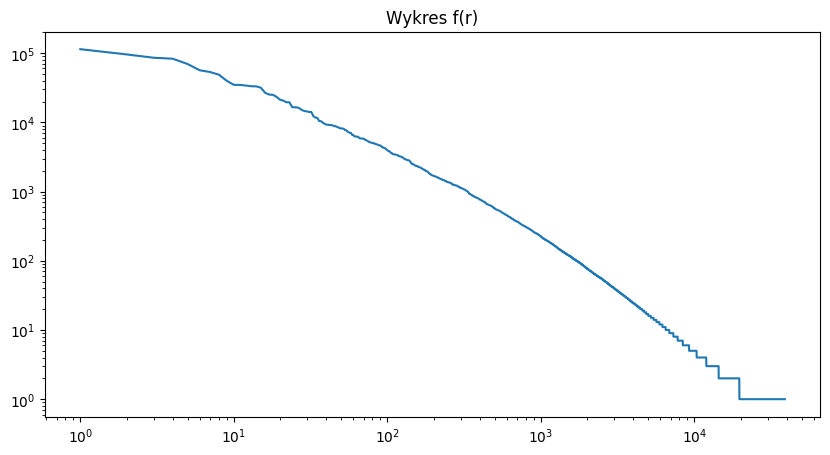

Top 20 słów: [('.', 114112), ('the', 95887), (',', 85879), ('i', 83088), ('a', 69655), ('and', 56566), ('it', 53388), ('to', 48835), ('of', 39818), ('>', 34838), ('<', 34724), ('is', 34024), ('/', 33233), ('br', 33131), ('this', 31685), (';', 26740), ('in', 25192), ('for', 24981), ('that', 23324), ('but', 21252)]


In [4]:
# Dane do wykresu f(r)
frequencies = [count for word, count in sorted_counts]
ranks = range(1, len(frequencies) + 1)

# Wykres
plt.figure(figsize=(10, 5))
plt.plot(ranks, frequencies)
plt.xscale('log'); plt.yscale('log')
plt.title("Wykres f(r)")
plt.show()

# 20 najczęstszych słów
print("Top 20 słów:", sorted_counts[:20])

In [5]:
# Podział na zbiór testowy i treningowy
lines = raw_txt.strip().split('\n')
reviews = []
labels = []

for line in lines:
    if ';' in line:
        # Rozdział linii na etykietę i treść 
        label, recenzja_raw = line.split(';', 1)
        
        # Tokenizacja i lemmatyzacja dla treści recenzji
        tokens = word_tokenize(recenzja_raw.lower())
        lemmed = [lemmatizer.lemmatize(t) for t in tokens if t.isalpha()]
        
        # Łączymy lematy w jeden tekst i dodajemy do listy
        reviews.append(" ".join(lemmed))
        labels.append(label)

In [6]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    reviews, labels, test_size=0.2, random_state=42
)
nltk.download('stopwords') 

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/gabusia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [7]:
# TF-IDF
stop_words_list = stopwords.words('english')

from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=2500, stop_words=stop_words_list, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf = tfidf.transform(X_test_raw)

In [8]:
# Trenowanie modelu
topologie = [
    {"nazwa": "Topologia 1 ", "layers": (64,)},
    {"nazwa": "Topologia 2", "layers": (128, 64)},
    {"nazwa": "Topologia 3", "layers": (128, 128, 128)}
]

for t in topologie:
    # Definicja sieci
    mlp = MLPClassifier(hidden_layer_sizes=t["layers"], activation='relu', max_iter=500, random_state=42)
    
    print(f"Trenowanie: {t['nazwa']}")
    mlp.fit(X_train_tfidf, y_train)

Trenowanie: Topologia 1 
Trenowanie: Topologia 2
Trenowanie: Topologia 3


In [11]:
# Dokładność
from sklearn.metrics import accuracy_score
train_acc = accuracy_score(y_train, mlp.predict(X_train_tfidf))
test_acc = accuracy_score(y_test, mlp.predict(X_test_tfidf))

print(f"Wynik treningowy: {train_acc:.2%}")
print(f"Wynik testowy: {test_acc:.2%}")

Wynik treningowy: 100.00%
Wynik testowy: 53.70%


Mam problem ze zrobieniem wyniku testowego powyżej 60%:((

<h4> Zadanie2: Wybierz dowolny zestaw polskich tekstów i na ich podstawie zbuduj model generujący kilka kolejnych słów (kolejne słowo, za każdym razem w oparciu o 2 (lub 3) poprzednie słowa). 
    
 <br>
 <br>

- Potestuj różne wymiary embeddingów, zmodyfikuj topologię sieci jeżeli to konieczne.
- Zadbaj o to żeby dane były spójne stylistycznie i tematycznie.
- Żeby generowane teksty były bardziej różnorodne możesz dodać wygładzanie Laplace'a. Z drugiej strony być może warto ograniczyć liczbę wszystkich słów.
- Nie musisz wydzielać zbioru treningowego/testowego.

In [20]:
nltk.download('punkt')

with open('calineczka.txt', 'r', encoding='utf-8') as f:
    raw_text = f.read()

# Tokenizacja:
tokens = [t.lower() for t in word_tokenize(raw_text) if t.isalpha()]

# Słownik
vocab = sorted(list(set(tokens)))
word_to_ix = {word: i for i, word in enumerate(vocab)}
vocab_size = len(vocab)

# N-gramy
CS = 2  # Rozmiar kontekstu 
N3_GM = list(ngrams(tokens, CS + 1))
N3_GM_formatted = [([x, y], z) for x, y, z in N3_GM]

[nltk_data] Downloading package punkt to /home/gabusia/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [21]:
# Model sieci
ED = 10 
HD = 16 

class NGramModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, context_size):
        super().__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.linear1 = nn.Linear(context_size * embedding_dim, HD)
        self.linear2 = nn.Linear(HD, vocab_size)

    def forward(self, inputs):
        embeds = self.embeddings(inputs).view((1, -1))
        out = F.relu(self.linear1(embeds))
        out = self.linear2(out)
        return out

# Inicjalizacja modelu
model = NGramModel(vocab_size, ED, CS)
loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)


In [ ]:
# Trenowanie
model.train()
for epoch in range(1000):
    total_loss = 0
    for context, target in N3_GM_formatted:
        # Konwersja słów na indeksy 
        context_idxs = torch.tensor([word_to_ix[w] for w in context], dtype=torch.long)
        
        model.zero_grad()
        log_probs = model(context_idxs)
        loss = loss_function(log_probs, torch.tensor([word_to_ix[target]], dtype=torch.long))
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

# Generowanie tekstu z wygładzeniem
def generate_next_words(seed_text, n_words=5, alpha=0.1):
    model.eval()
    current_context = word_tokenize(seed_text.lower())[-(CS):]
    result = list(current_context)
    
    with torch.no_grad():
        for _ in range(n_words):
            context_idxs = torch.tensor([word_to_ix[w] for w in current_context], dtype=torch.long)
            preds = model(context_idxs) 
            
            # Softmax
            probs = F.softmax(preds, dim=1).numpy()[0]
            
            # Wygładzenie
            smoothed_probs = (probs + alpha) / (probs.sum() + alpha * len(probs))
            
            # Losowanie słowa na podstawie rozkładu 
            next_idx = np.random.choice(len(smoothed_probs), p=smoothed_probs)
            next_word = vocab[next_idx]
            
            result.append(next_word)
            current_context = result[-(CS):]
            
    return " ".join(result)

print("\nWygenerowany tekst:")
print(generate_next_words("była raz", n_words=6, alpha=0.05))

<h4> Zad 3</h4>